<a href="www.google.com"><b>An Implementation of Kernel Logistic Regression: <i>KernelLogisticRegression.py</i></b></a>

# Introduction 

In the <a href="https://dcruzeneil.github.io/posts/gradient-descent/">previous blog post</a>, we looked at Logistic Regression with Gradient Descent, which worked well for binary classification of data with linear decision boundaries. However, in this blog post we aim to:
<ol>
    <li> Appreciate the limitations of that approach by working with data that does not have Linear Decision Boundaries
    <li> Implement <u><i>Kernel</i></u> Logistic Regression and use that for binary classification of data that does not have Linear Decision Boundaries 
</ol>
Before we get started, let us get an understanding of what data with "non-linear decision boundaries" means. So far, we have been dealing with the "construction" of the best line which separates the data into one group or the other, however if you look at this data:
<br><br><center><img src="nonlinear.png" width=450 height=400/></center>

<br>Visually, it is pretty apparent that the data follows a circular pattern, with the two "classes" having different radii (varying distance from the center). So it is pretty apparent that if we tried our implementation of Logistic Regression with Gradient Descent, it would not do well since by the inherent nature of this data - there are no linear decision boundaries. 

# Logistic Regression versus Kernel Logistic Regression on Data with Non-Linear Decision Boundaries

In this section, we aim to understand the performance difference of <i>Logistic Regression</i> and <i>Kernel Logistic Regression</i> by generating some data which has clear non-linear decision boundaries. For the <i>Kernel Logistic Regression</i> we will be using the code that I wrote, however for the <i>Logistic Regression</i> we will be using scikit-learn's model. Let us go ahead and generate some synthetic data:

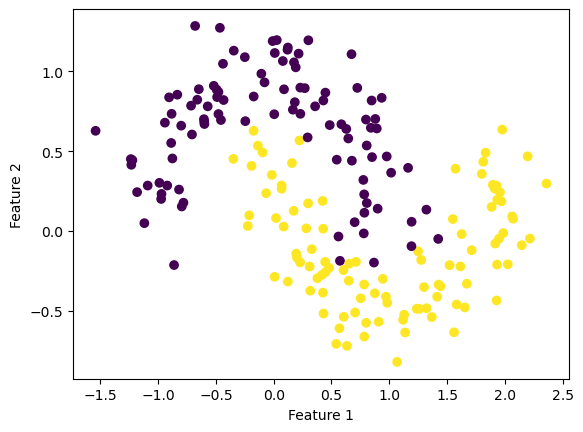

In [24]:
from KernelLogisticRegression import KernelLogisticRegression
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.datasets import make_moons, make_circles
from matplotlib import pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LogisticRegression
import numpy as np
np.seterr(all="ignore")

X, y = make_moons(200, shuffle = True, noise = 0.2)

#visualizing the data
plt.scatter(X[:,0], X[:,1], c = y)
labels = plt.gca().set(xlabel = "Feature 1", ylabel = "Feature 2")

Clearly, the data above has non-linear decision boundaries and follows a "moon" like shape. Now, let us go ahead and fit our version of <i>Kernel Logistic Regression</i> and scikit-learn's <i>Logistic Regression</i> on the data:

In [26]:
#Regular logistic Regression 
LR = LogisticRegression()
LR.fit(X, y)

#Kernel Logistic Regression
KLR = KernelLogisticRegression(rbf_kernel, gamma = 10)
KLR.fit(X, y)

Now, we can go ahead and visualize how our two models performed:

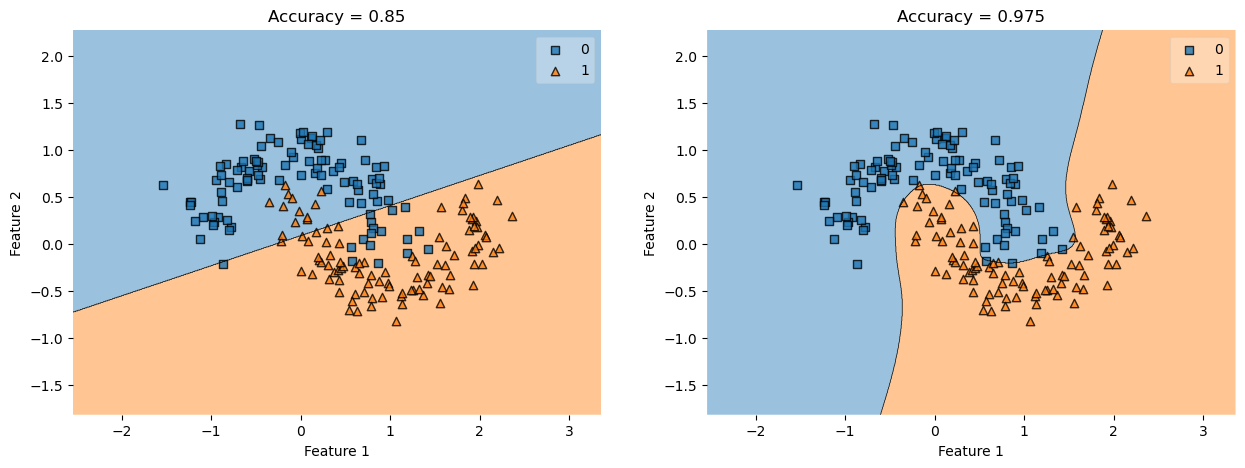

In [37]:
plt.rcParams["figure.figsize"] = (15, 5)
fig, ax = plt.subplots(1, 2)

#plotting regular Logistic Regression
plot_decision_regions(X, y, clf = LR, ax=ax[0])
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')
ax[0].set_title(f"Accuracy = {(LR.score(X,y))}")

#plotting regular Logistic Regression
plot_decision_regions(X, y, clf = KLR, ax=ax[1])
ax[1].set_xlabel('Feature 1')
ax[1].set_ylabel('Feature 2')
ax[1].set_title(f"Accuracy = {(KLR.score(X,y))}")

plt.show()

Therefore, we can clearly see how regular logistic regression, finds the best "straight line" that divides the two classes. However, it is not able to learn the "curvy" nature of the data. On the other hand, kernel logistic regression is able to learn that "curvy" nature, and therefore has a better performance at our classification task. 

# What is Kernel Logistic Regression?
Originally, when we were dealing with Logistic Regression, our empirical risk minimization problem was:<br><br>
<center> $\hat{\mathbf{w}} = \mathop{\mathrm{arg\,min}}_{\mathbf{w}} \; L(\mathbf{w})\;$ </center>
<br>where, our loss function $L(\mathbf{w})\;$ was defined as:<br><br>
<center> $L(\mathbf{w}) = \frac{1}{n} \sum_{i = 1}^n \ell(\langle \mathbf{w}, \mathbf{x}_i \rangle, y_i)\;$ </center>
<br>Now, in Kernel Logistic Regression, we want to map our original features onto a higher-dimensional space, where it possible to linearly classify our data, for this purpose our empirical risk minimization problem becomes:
<center> $L_k(\mathbf{v}) = \frac{1}{n} \sum_{i = 1}^n \ell(\langle \mathbf{v}, \boldsymbol{\kappa}(\mathbf{x}_i) \rangle, y_i)\;
\tag{1}$ </center>

<br>Basically, what we do is we take the rows of the original feature matrix $X$: $x_i$, and perform the mapping $\boldsymbol{\kappa}(\mathbf{x}_i)$ on it. Performing this operation on a feature row $x_i$ results in a modified feature vector $\boldsymbol{\kappa}(\mathbf{x}_i)$, which has entries:

<center> $\boldsymbol{\kappa}(\mathbf{x}_i) = \left( \begin{matrix}
    k(\mathbf{x}_1, \mathbf{x}_i) \\
    k(\mathbf{x}_2, \mathbf{x}_i) \\
    \vdots \\
    k(\mathbf{x}_n, \mathbf{x}_i)
\end{matrix}\right)\;$ </center>
<br>Here, $k(\mathbf{x}_1, \mathbf{x}_i)$ performs the kernel operation between two feature rows, and produces a single-value which for simplicity can be understood as the "similarity" between these two feature rows. Performing this operation on every feature row of the original feature matrix, with respect to every other feature row of the original feature matrix gives us the <u>kernel matrix</u><br>:
<center> $\boldsymbol{\kappa}(\mathbf{X}) = \left( \begin{matrix}
    k(\mathbf{x}_1, \mathbf{x}_1) \hspace{1cm} k(\mathbf{x}_1, \mathbf{x}_2) \hspace{1cm} k(\mathbf{x}_1, \mathbf{x}_3) \hspace{1cm} k(\mathbf{x}_1, \mathbf{x}_n) \\
    k(\mathbf{x}_2, \mathbf{x}_1) \hspace{1cm} k(\mathbf{x}_2, \mathbf{x}_2) \hspace{1cm} k(\mathbf{x}_2, \mathbf{x}_3) \hspace{1cm} k(\mathbf{x}_2, \mathbf{x}_n)\\
    \vdots \\
    k(\mathbf{x}_n, \mathbf{x}_1) \hspace{1cm} k(\mathbf{x}_n, \mathbf{x}_2) \hspace{1cm} k(\mathbf{x}_n, \mathbf{x}_3) \hspace{1cm} k(\mathbf{x}_n, \mathbf{x}_n))
\end{matrix}\right)\;$ </center>

<br>Therefore, in the <u>kernel matrix</u> $\boldsymbol{\kappa}(\mathbf{X})$, each column $i$ corresponds to the kernel operation done for the $i$th row of the original feature matrix, with respect to all feature rows in the original feature matrix. Therefore, we can see that our original feature matrix $X \in \mathbb{R}^{nxp}$, becomes the kernel matrix $\boldsymbol{\kappa}(\mathbf{X}) \in \mathbb{R}^{nxn}$, with more features we are in a better position to study the data in a higher-dimensional space. However, the fact that our matrix is now $nxn$ means that we need to modify our weight vector as well. Our original feature vector was $w \in \mathbb{R}^{p}$, but now our modified weight vector is $v \in \mathbb{R}^{n}$. For each column $i$ of the kernel matrix, the prediction is performed as follows:<br><br>
<center>$\hat{y} = \langle \hat{\mathbf{v}}, \boldsymbol{\kappa}(\mathbf{x_i}) \rangle\;$</center>

<br><u>Important Note:</u> By definition, a regular multiplication of the feature matrix and the weight vector happens along the rows of the matrix, rather than the columns. However, by the properties of a kernel matrix created between the same matrix twice, we are guaranteed symmetry - so we do not need to transpose the matrix. This idea of transposition will become relevant when we perform the prediction function on unseen data (a new feature matrix).

# Implementation and Explanation of Code